Importing Datasets and Packages

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [6]:
crops_df=pd.read_csv("/content/Crop_recommendation.csv")

In [7]:
crops_df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [9]:
crops_df=crops_df.rename(columns={'label':'crops'})

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
le=LabelEncoder()

In [12]:
y = le.fit_transform(crops_df["crops"])

In [13]:
# Map encoded labels back to crop names
for i, crop in enumerate(le.classes_):
    print(f"{i} -> {crop}")

0 -> apple
1 -> banana
2 -> blackgram
3 -> chickpea
4 -> coconut
5 -> coffee
6 -> cotton
7 -> grapes
8 -> jute
9 -> kidneybeans
10 -> lentil
11 -> maize
12 -> mango
13 -> mothbeans
14 -> mungbean
15 -> muskmelon
16 -> orange
17 -> papaya
18 -> pigeonpeas
19 -> pomegranate
20 -> rice
21 -> watermelon


In [14]:
X = crops_df.drop('crops', axis=1)
# y = crops_df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [19]:
model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(len(np.unique(y_encoded)), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,796 (147.64 KB)

 Trainable params: 12,470 (48.71 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 24,942 (97.43 KB)

In [20]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [21]:
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=200,
                    batch_size=32,
                    callbacks=[es],
                    verbose=1)

Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.0870 - loss: 3.2056 - val_accuracy: 0.4574 - val_loss: 2.8177
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4114 - loss: 2.0451 - val_accuracy: 0.6932 - val_loss: 2.3772
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6673 - loss: 1.3551 - val_accuracy: 0.7983 - val_loss: 1.7977
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7521 - loss: 0.9653 - val_accuracy: 0.9148 - val_loss: 1.2472
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7970 - loss: 0.7116 - val_accuracy: 0.9261 - val_loss: 0.8306
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8648 - loss: 0.5367 - val_accuracy: 0.9631 - val_loss: 0.5260
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8851 - loss: 0.4456 - val_accuracy: 0.9716 - val_loss: 0.3347
Epoch 8/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8877 - loss: 0.3966 - val_accuracy: 0.9744 - 

In [23]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.9932


In [28]:
y_prob=model.predict(X_test)
y_prob

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([[8.55061334e-12, 5.79857326e-15, 3.22540501e-11, ...,
        9.07102105e-07, 1.01730506e-10, 2.93931746e-09],
       [5.77324748e-08, 9.99593973e-01, 1.60886393e-05, ...,
        1.11946621e-08, 2.41571479e-06, 1.04707385e-06],
       [7.15544364e-14, 2.65495359e-08, 3.13523027e-11, ...,
        4.48838709e-12, 4.76080757e-08, 5.15268803e-05],
       ...,
       [1.20675554e-06, 8.91491800e-05, 1.21844266e-07, ...,
        2.05001152e-06, 2.01502256e-02, 9.37669029e-07],
       [1.59499302e-06, 7.63100388e-07, 8.14627210e-09, ...,
        9.04087916e-10, 1.87537624e-11, 6.75510023e-07],
       [8.05415766e-06, 4.30826468e-08, 1.28887302e-06, ...,
        1.64672258e-08, 2.11898191e-06, 2.14401153e-11]], dtype=float32)

In [30]:
y_pred = y_prob.argmax(axis=1)
y_pred

array([16,  1,  6, 11, 16,  3, 20,  2,  1, 16, 21, 19, 21, 11, 13,  7,  7,
       12, 12,  0,  2,  0, 13,  9,  0,  8, 12, 21, 20,  5, 12,  8,  1,  5,
        8,  2,  7,  7,  2,  8,  4, 17, 12, 11, 10,  8,  6, 10,  3, 14, 17,
       19, 18, 21, 12,  2, 17, 17,  5, 10, 10, 13,  5,  1, 17, 20, 16,  4,
        2, 19,  1, 15, 21, 10,  1,  4, 13, 14, 14, 12,  5, 21, 15,  9, 12,
       19, 16,  6,  4, 17, 13, 14, 13,  6,  8,  7,  6,  3,  8, 21, 15, 19,
       16, 18, 18,  7,  9, 10, 20, 20,  0, 14, 14,  7, 20, 15,  2, 10,  1,
       16, 16,  3, 11, 12, 11, 10,  1, 19,  4, 14,  6,  3,  8, 14, 13, 11,
        0,  3, 20, 11,  6,  8, 19, 12, 20, 17,  1, 16, 18, 10, 11,  3,  6,
       21, 13, 11, 18, 15,  0, 14,  2,  3, 11, 11,  9,  5, 16, 11,  7, 19,
        0,  4, 15,  7,  6, 10, 18,  3,  2, 13,  0, 15,  6, 21, 15, 21, 16,
       21,  5,  9,  0,  3,  2,  5, 15,  5,  0,  7,  8, 17,  4,  7, 21, 14,
       19, 18, 14, 10, 17, 15,  3,  0, 11,  3,  1, 19, 19, 11, 16,  8,  6,
        6, 11,  7, 14, 10

In [31]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9931818181818182

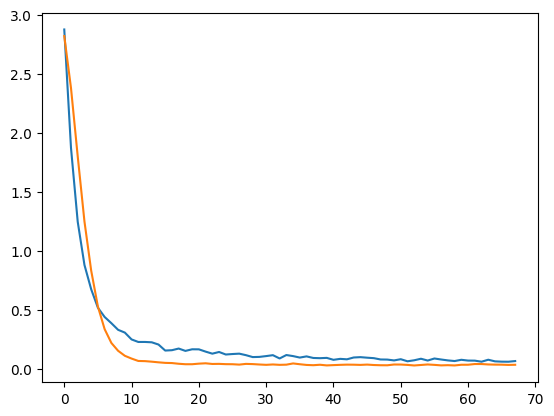

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

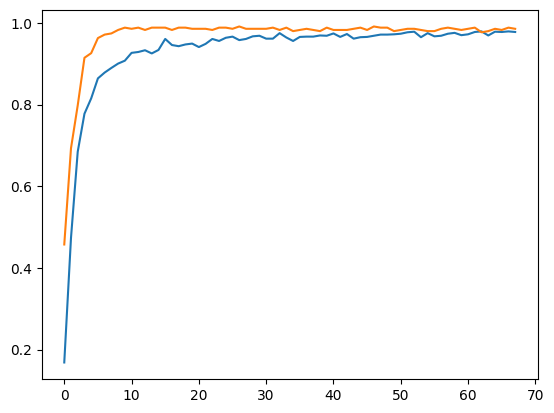

In [33]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [24]:
print(y_test.shape)
print(model.predict(X_test).shape)


(440,)
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
(440, 22)


In [25]:
print(le.classes_)
print(type(le.classes_))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
<class 'numpy.ndarray'>


In [26]:
y_pred = model.predict(X_test).argmax(axis=1)
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       0.95      1.00      0.98        20
          11       1.00      1.00      1.00        20
          12       0.95      1.00      0.98        20
          13       1.00      0.90      0.95        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.



---



---


***2nd Model to improve accuracy***

---



---



In [34]:
crops_df.head()

,N,P,K,temperature,humidity,ph,rainfall,crops
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [35]:
y

array([20, 20, 20, ...,  5,  5,  5])

In [36]:
y_encoded

array([20, 20, 20, ...,  5,  5,  5])

In [38]:
crops_df_encoded = crops_df.drop('crops', axis=1).copy()
crops_df_encoded['crops'] = y_encoded
crops_df_encoded.head()

,N,P,K,temperature,humidity,ph,rainfall,crops
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20


In [45]:
crops_df_encoded.corr()['crops']

,crops
N,-0.031130
P,-0.491006
K,-0.346417
temperature,0.113606
humidity,0.193911
ph,-0.012253
rainfall,0.045611
crops,1.000000


In [46]:
X_train

array([[-1.36963605, -1.07230015, -0.67439784, ...,  0.92212812,
         0.9544426 ,  0.19933287],
       [-1.1257927 ,  2.08128059,  3.01859638, ...,  0.42399345,
        -1.16210125, -0.64426071],
       [-1.07160529,  0.53481311, -0.47691151, ..., -2.1907583 ,
        -1.11514907,  0.69417407],
       ...,
       [ 0.85204776, -0.1626134 , -0.23992793, ...,  0.46216703,
        -0.15173053,  1.6339379 ],
       [ 1.0687974 , -0.10196761, -0.08193887, ...,  0.09006708,
        -0.27924772,  1.23772632],
       [-1.34254234,  2.38450951,  2.99884775, ...,  0.51489508,
        -1.09689372, -0.67137001]])

In [47]:
X_test

array([[-1.01741788, -0.92068569, -0.83238689, ...,  0.84381648,
         1.15779569, -0.01397348],
       [ 1.28554704,  0.77739624,  0.03655292, ...,  0.58365512,
        -0.04337609, -0.22565328],
       [ 2.42348265, -0.46584232, -0.6546492 , ...,  0.19772928,
        -0.57904197, -0.61056463],
       ...,
       [ 0.5269233 , -0.46584232, -0.25967656, ...,  0.34983266,
         0.70381337,  1.10665308],
       [-0.80066824,  2.44515529,  3.03834501, ...,  0.38364808,
        -0.05694277, -0.69460045],
       [-0.39426267,  0.41352154, -0.45716288, ..., -1.57034738,
        -0.06645122,  0.59298368]])

In [48]:
y_train

array([16,  7,  9, ...,  8,  8,  7])

In [49]:
y_test

array([16,  1,  6, 11, 16,  3, 20,  2,  1, 16, 21, 19, 21, 11, 13,  7,  7,
       12, 12,  0,  2,  0, 13,  9,  0,  8, 13, 21, 20,  5, 12,  8,  1,  5,
        8,  2,  7,  7,  2,  8,  4, 17, 12, 11, 10,  8,  6, 10,  3, 14, 17,
       19, 18, 21, 12,  2, 17, 17,  5, 10, 10, 13,  5,  1, 17, 20, 16,  4,
        2, 19,  1, 15, 21, 10,  1,  4, 13, 14, 14, 12,  5, 21, 15,  9, 12,
       19, 16,  6,  4, 17, 13, 14, 13,  6,  8,  7,  6,  3,  8, 21, 15, 19,
       16, 18, 18,  7,  9, 10, 20, 20,  0, 14, 14,  7, 20, 15,  2, 10,  1,
       16, 16,  3, 11, 12, 11, 10,  1, 19,  4, 14,  6,  3,  8, 14, 13, 11,
        0,  3, 20, 11,  6,  8, 19, 12, 20, 17,  1, 16, 18, 10, 11,  3,  6,
       21, 13, 11, 18, 15,  0, 14,  2,  3, 11, 11,  9,  5, 16, 11,  7, 19,
        0,  4, 15,  7,  6, 10, 18,  3,  2, 13,  0, 15,  6, 21, 15, 21, 16,
       21,  5,  9,  0,  3,  2,  5, 15,  5,  0,  7,  8, 17,  4,  7, 21, 14,
       19, 18, 14, 10, 17, 15,  3,  0, 11,  3,  1, 19, 19, 11, 16,  8,  6,
        6, 11,  7, 14, 10

In [50]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Dropout, BatchNormalization


In [52]:
X_train.shape[1]

7

In [64]:
model=Sequential()
model.add(Dense(128,activation='relu',input_dim=7))
model.add(Dense(64,activation='sigmoid'))

model.compile(optimizer='Adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [65]:
model.fit(X_train,y_train,batch_size=32,epochs=100,validation_data=(X_test,y_test))

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1606 - loss: 3.8138 - val_accuracy: 0.5636 - val_loss: 2.7013
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6409 - loss: 2.3540 - val_accuracy: 0.7591 - val_loss: 1.5133
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7933 - loss: 1.3155 - val_accuracy: 0.8477 - val_loss: 0.9371
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8557 - loss: 0.8620 - val_accuracy: 0.9068 - val_loss: 0.6713
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9013 - loss: 0.6230 - val_accuracy: 0.9182 - val_loss: 0.5228
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9131 - loss: 0.5045 - val_accuracy: 0.9273 - val_loss: 0.4247
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9394 - loss: 0.4060 - val_accuracy: 0.9409 - val_loss: 0.3577
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9307 - loss: 0.3618 - val_accuracy: 0.9455 - 

1. How to select appropriate optimizer
2. no of nodes in a layer
3. how to select no. of layers
4. all in all one model

In [70]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 9.7 MB/s eta 0:00:00


In [71]:
import keras_tuner as kt

In [72]:
def build_model(hp):
  model=Sequential()
  model.add(Dense(128,activation='relu',input_dim=7))
  model.add(Dense(64,activation='sigmoid'))

  model.compile(optimizer=hp.Choice('optimizer',values=['adam',
                                                 'sgd',
                                                 'rmsprop',
                                                 'adamw',
                                                 'adadelta',
                                                 'adagrad',
                                                 'adamax',
                                                 'adamax',
                                                 'adafactor',
                                                 'nadam',
                                                 'ftrl',
                                                 'lion',
                                                 'lamb',
                                                 'loss scale optimizer',
                                                 'muon']),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
  return model

In [73]:
tuner=kt.RandomSearch(build_model,
                      objective='val_accuracy',
                      max_trials=5,
                      )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [74]:
tuner.search(X_train,y_train,epochs=50,validation_data=(X_test,y_test))

Trial 5 Complete [00h 00m 01s]

Best val_accuracy So Far: 0.9909090995788574
Total elapsed time: 00h 01m 04s


In [78]:
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'nadam'}

In [79]:
model=tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 11 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [80]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,280 (36.25 KB)

 Trainable params: 9,280 (36.25 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
model.fit(X_train,y_train,batch_size=32,epochs=100,initial_epoch=6,validation_data=(X_test,y_test))

Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9938 - loss: 0.0330 - val_accuracy: 0.9886 - val_loss: 0.0440
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9905 - loss: 0.0397 - val_accuracy: 0.9864 - val_loss: 0.0436
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9897 - loss: 0.0404 - val_accuracy: 0.9841 - val_loss: 0.0412
Epoch 10/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9941 - loss: 0.0349 - val_accuracy: 0.9909 - val_loss: 0.0393
Epoch 11/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9928 - loss: 0.0306 - val_accuracy: 0.9864 - val_loss: 0.0398
Epoch 12/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9916 - loss: 0.0335 - val_accuracy: 0.9864 - val_loss: 0.0430
Epoch 13/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9944 - loss: 0.0307 - val_accuracy: 0.9932 - val_loss: 0.0356
Epoch 14/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9930 - loss: 0.0258 - val_accuracy: 0.99

In [99]:
def built_model(hp):
  model=Sequential()
  units=hp.Int('units',min_value=120,max_value=256)
  model.add(Dense(units=units,activation='relu',input_dim=7))
  model.add(Dense(22,activation='sigmoid'))

  model.compile(optimizer='nadam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

  return model

In [101]:
tuner2=kt.RandomSearch(built_model,
                      objective='val_accuracy',
                      max_trials=10,
                       directory='mydir1',
                       project_name='2')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [102]:
tuner2.search(X_train,y_train,epochs=50,validation_data=(X_test,y_test))

Trial 10 Complete [00h 00m 16s]
val_accuracy: 0.9931818246841431

Best val_accuracy So Far: 0.9954545497894287
Total elapsed time: 00h 02m 37s


In [103]:
tuner2.get_best_hyperparameters()[0].values

{'units': 234}

In [104]:
model2=tuner2.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 11 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [105]:
model2.fit(X_train,y_train,batch_size=32,epochs=100,initial_epoch=11,validation_data=(X_test,y_test))

Epoch 12/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9914 - loss: 0.0349 - val_accuracy: 0.9909 - val_loss: 0.0371
Epoch 13/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9914 - loss: 0.0324 - val_accuracy: 0.9909 - val_loss: 0.0373
Epoch 14/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9957 - loss: 0.0273 - val_accuracy: 0.9909 - val_loss: 0.0343
Epoch 15/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9883 - loss: 0.0387 - val_accuracy: 0.9909 - val_loss: 0.0318
Epoch 16/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9926 - loss: 0.0266 - val_accuracy: 0.9841 - val_loss: 0.0384
Epoch 17/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9907 - loss: 0.0330 - val_accuracy: 0.9841 - val_loss: 0.0382
Epoch 18/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9905 - loss: 0.0277 - val_accuracy: 0.9886 - val_loss: 0.0302
Epoch 19/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9935 - loss: 0.0273 - val_accuracy: 0

In [109]:
def build_model(hp):
  model=Sequential()
  model.add(Dense(234,activation='relu',input_dim=7))
  for i in range(hp.Int('num_layers',min_value=1,max_value=10)):
    model.add(Dense(234,activation='relu'))
  model.add(Dense(22,activation='softmax'))
  model.compile(optimizer='nadam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
  return model

In [110]:
tuner3=kt.RandomSearch(build_model,
                       objective='val_accuracy',
                       max_trials=3,
                       directory='mydir2',
                       project_name='4'
                       )

In [111]:
tuner3.search(X_train,y_train,epochs=50,validation_data=(X_test,y_test))

Trial 3 Complete [00h 00m 17s]
val_accuracy: 0.9931818246841431

Best val_accuracy So Far: 0.9977272748947144
Total elapsed time: 00h 01m 05s


In [112]:
tuner3.get_best_hyperparameters()[0].values

{'num_layers': 10}

In [114]:
model=tuner3.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 51 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [116]:
model.fit(X_train,y_train,epochs=100,initial_epoch=4,validation_data=(X_test,y_test))

Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9871 - loss: 0.0484 - val_accuracy: 0.9818 - val_loss: 0.0775
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9849 - loss: 0.0586 - val_accuracy: 0.9682 - val_loss: 0.1414
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9851 - loss: 0.0734 - val_accuracy: 0.9750 - val_loss: 0.1302
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9754 - loss: 0.0978 - val_accuracy: 0.9795 - val_loss: 0.1045
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9919 - loss: 0.0319 - val_accuracy: 0.9795 - val_loss: 0.0809
Epoch 10/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9920 - loss: 0.0165 - val_accuracy: 0.9705 - val_loss: 0.1274
Epoch 11/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9882 - loss: 0.0244 - val_accuracy: 0.9750 - val_loss: 0.0893
Epoch 12/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9971 - loss: 0.0171 - val_accuracy: 0.9795

In [136]:
def build_model(hp):

  model=Sequential()

  counter=0

  for i in range(hp.Int('num_layers',min_value=1,max_value=20)):
    if counter==0:
      model.add(Dense(
          hp.Int('units'+str(i),min_value=120,max_value=256,step=8),
          activation=hp.Choice('activation'+str(i),values=['tanh',
                                                           'relu',
                                                           'elu',
                                                           'sigmoid',
                                                           'gelu']),
          input_dim=7
          )
      )
    else:
      model.add(Dense(
          hp.Int('units'+str(i),min_value=120,max_value=256,step=8),
          activation=hp.Choice('activation'+str(i),values=['tanh',
                                                           'relu',
                                                           'elu',
                                                           'sigmoid',
                                                           'gelu']),
          )
      )
    counter+=1;

  model.add(Dense(22,activation='softmax'))

  model.compile(optimizer=hp.Choice('optimizer',values=['adam',
                                                 'sgd',
                                                 'rmsprop',
                                                 'adamw',
                                                 'adadelta',
                                                 'adagrad',
                                                 'adamax',
                                                 'nadam',]),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
  return model

In [137]:
tuner5=kt.RandomSearch(build_model,
                       objective='val_accuracy',
                       max_trials=10,
                       directory="final_model",
                       project_name="final4"
                       )

In [138]:
tuner5.search(X_train,y_train,epochs=100,validation_data=(X_test,y_test))

Trial 10 Complete [00h 00m 48s]
val_accuracy: 0.04545454680919647

Best val_accuracy So Far: 0.9954545497894287
Total elapsed time: 00h 07m 13s


In [139]:
tuner5.get_best_hyperparameters()[0].values

{'num_layers': 6,
 'units0': 256,
 'activation0': 'gelu',
 'optimizer': 'nadam',
 'units1': 136,
 'activation1': 'elu',
 'units2': 256,
 'activation2': 'gelu',
 'units3': 256,
 'activation3': 'relu',
 'units4': 192,
 'activation4': 'tanh',
 'units5': 192,
 'activation5': 'gelu',
 'units6': 184,
 'activation6': 'relu',
 'units7': 120,
 'activation7': 'relu',
 'units8': 168,
 'activation8': 'tanh',
 'units9': 176,
 'activation9': 'gelu',
 'units10': 224,
 'activation10': 'elu',
 'units11': 200,
 'activation11': 'elu',
 'units12': 120,
 'activation12': 'elu',
 'units13': 256,
 'activation13': 'tanh',
 'units14': 208,
 'activation14': 'elu',
 'units15': 176,
 'activation15': 'sigmoid',
 'units16': 208,
 'activation16': 'relu',
 'units17': 232,
 'activation17': 'sigmoid'}

In [140]:
model=tuner5.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 31 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [141]:
model.fit(X_train,y_train,epochs=100,initial_epoch=10,validation_data=(X_test,y_test))

Epoch 11/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9961 - loss: 0.0151 - val_accuracy: 0.9932 - val_loss: 0.0279
Epoch 12/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9929 - loss: 0.0297 - val_accuracy: 0.9682 - val_loss: 0.0899
Epoch 13/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9915 - loss: 0.0294 - val_accuracy: 0.9795 - val_loss: 0.0818
Epoch 14/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9881 - loss: 0.0213 - val_accuracy: 0.9886 - val_loss: 0.0252
Epoch 15/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9973 - loss: 0.0055 - val_accuracy: 0.9932 - val_loss: 0.0258
Epoch 16/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9988 - loss: 0.0031 - val_accuracy: 0.9864 - val_loss: 0.0384
Epoch 17/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9967 - loss: 0.0126 - val_accuracy: 0.9795 - val_loss: 0.0724
Epoch 18/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9955 - loss: 0.0193 - val_accuracy: 0

---
---
***More Optimization on model***
---
---
---



In [142]:
from keras.layers import Dropout

In [143]:
def build_model(hp):

  model=Sequential()

  counter=0

  for i in range(hp.Int('num_layers',min_value=1,max_value=20)):
    if counter==0:
      model.add(Dense(
          hp.Int('units'+str(i),min_value=120,max_value=256,step=8),
          activation=hp.Choice('activation'+str(i),values=['tanh',
                                                           'relu',
                                                           'elu',
                                                           'sigmoid',
                                                           'gelu']),
          input_dim=7
          )
      )
      model.add(Dropout(hp.Choice('dropout'+str(i),values=[0.1,
                                                           0.2,
                                                           0.3,
                                                           0.4,
                                                           0.5,
                                                           0.6,
                                                           0.7,
                                                           0.8,
                                                           0.9])))
    else:
      model.add(Dense(
          hp.Int('units'+str(i),min_value=120,max_value=256,step=8),
          activation=hp.Choice('activation'+str(i),values=['tanh',
                                                           'relu',
                                                           'elu',
                                                           'sigmoid',
                                                           'gelu']),
          )
      )
      model.add(Dropout(hp.Choice('dropout'+str(i),values=[0.1,
                                                           0.2,
                                                           0.3,
                                                           0.4,
                                                           0.5,
                                                           0.6,
                                                           0.7,
                                                           0.8,
                                                           0.9])))
    counter+=1;

  model.add(Dense(22,activation='softmax'))

  model.compile(optimizer=hp.Choice('optimizer',values=['adam',
                                                 'sgd',
                                                 'rmsprop',
                                                 'adamw',
                                                 'adadelta',
                                                 'adagrad',
                                                 'adamax',
                                                 'nadam',]),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
  return model

In [144]:
tuner10=kt.RandomSearch(build_model,
                       objective='val_accuracy',
                       max_trials=10,
                       directory="final_model_opt",
                       project_name="final1"
                       )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [145]:
tuner10.search(X_train,y_train,epochs=100,validation_data=(X_test,y_test))

Trial 10 Complete [00h 00m 54s]
val_accuracy: 0.04545454680919647

Best val_accuracy So Far: 0.9954545497894287
Total elapsed time: 00h 08m 06s


In [146]:
tuner10.get_best_hyperparameters()[0].values

{'num_layers': 4,
 'units0': 128,
 'activation0': 'tanh',
 'dropout0': 0.2,
 'optimizer': 'nadam',
 'units1': 120,
 'activation1': 'tanh',
 'dropout1': 0.1,
 'units2': 120,
 'activation2': 'tanh',
 'dropout2': 0.1,
 'units3': 120,
 'activation3': 'tanh',
 'dropout3': 0.1}

In [147]:
best_model=tuner10.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 23 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [157]:
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history10=best_model.fit(X_train,y_train,epochs=200,initial_epoch=10,validation_data=(X_test,y_test),callbacks=[es])

Epoch 11/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9876 - loss: 0.0338 - val_accuracy: 0.9886 - val_loss: 0.0211
Epoch 12/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9914 - loss: 0.0287 - val_accuracy: 0.9932 - val_loss: 0.0198
Epoch 13/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9918 - loss: 0.0321 - val_accuracy: 0.9864 - val_loss: 0.0444
Epoch 14/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9856 - loss: 0.0394 - val_accuracy: 0.9909 - val_loss: 0.0360
Epoch 15/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9886 - loss: 0.0284 - val_accuracy: 0.9955 - val_loss: 0.0262
Epoch 16/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0309 - val_accuracy: 0.9955 - val_loss: 0.0191
Epoch 17/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9818 - loss: 0.0472 - val_accuracy: 0.9886 - val_loss: 0.0228
Epoch 18/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9786 - loss: 0.0481 - val_accuracy: 0.

In [158]:
y_prob = best_model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [159]:
y_pred = y_prob.argmax(axis=1)

In [160]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9954545454545455

***Introducing BatchNormalisations,Dropouts and early stopping***

In [167]:
def build_model(hp):

  model=Sequential()

  counter=0

  for i in range(hp.Int('num_layers',min_value=1,max_value=20)):
    if counter==0:
      model.add(Dense(
          hp.Int('units'+str(i),min_value=120,max_value=256,step=8),
          activation=hp.Choice('activation'+str(i),values=['tanh',
                                                           'relu',
                                                           'elu',
                                                           'sigmoid',
                                                           'gelu']),
          input_dim=7
          )
      )
      model.add(BatchNormalization())
      model.add(Dropout(hp.Choice('dropout'+str(i),values=[0.1,
                                                           0.2,
                                                           0.3,
                                                           0.4,
                                                           0.5,
                                                           0.6,
                                                           0.7,
                                                           0.8,
                                                           0.9])))
    else:
      model.add(Dense(
          hp.Int('units'+str(i),min_value=120,max_value=256,step=8),
          activation=hp.Choice('activation'+str(i),values=['tanh',
                                                           'relu',
                                                           'elu',
                                                           'sigmoid',
                                                           'gelu']),
          )
      )
      model.add(BatchNormalization())
      model.add(Dropout(hp.Choice('dropout'+str(i),values=[0.1,
                                                           0.2,
                                                           0.3,
                                                           0.4,
                                                           0.5,
                                                           0.6,
                                                           0.7,
                                                           0.8,
                                                           0.9])))
    counter+=1;

  model.add(Dense(22,activation='softmax'))

  model.compile(optimizer=hp.Choice('optimizer',values=['adam',
                                                 'sgd',
                                                 'rmsprop',
                                                 'nadam',]),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
  return model

In [168]:
tuner15=kt.RandomSearch(build_model,
                       objective='val_accuracy',
                       max_trials=10,
                       directory="final_model_opt_1",
                       project_name="final2"
                       )

In [169]:
# tuner15.search(X_train,y_train,epochs=100,validation_data=(X_test,y_test),batch_size=hp.Choice('batch_size', [16, 32, 64, 128]))

for bs in [16, 32, 64, 128]:
    tuner15.search(
        X_train, y_train,
        epochs=50,
        validation_data=(X_test, y_test),
        batch_size=bs
    )

Trial 10 Complete [00h 00m 30s]
val_accuracy: 0.9318181872367859

Best val_accuracy So Far: 0.9977272748947144
Total elapsed time: 00h 07m 23s


In [170]:
tuner15.get_best_hyperparameters()[0].values

{'num_layers': 2,
 'units0': 168,
 'activation0': 'relu',
 'dropout0': 0.2,
 'optimizer': 'sgd',
 'units1': 256,
 'activation1': 'gelu',
 'dropout1': 0.2,
 'units2': 144,
 'activation2': 'relu',
 'dropout2': 0.9,
 'units3': 160,
 'activation3': 'gelu',
 'dropout3': 0.4,
 'units4': 128,
 'activation4': 'sigmoid',
 'dropout4': 0.9,
 'units5': 144,
 'activation5': 'elu',
 'dropout5': 0.5,
 'units6': 232,
 'activation6': 'sigmoid',
 'dropout6': 0.3,
 'units7': 136,
 'activation7': 'sigmoid',
 'dropout7': 0.2,
 'units8': 176,
 'activation8': 'sigmoid',
 'dropout8': 0.6,
 'units9': 160,
 'activation9': 'tanh',
 'dropout9': 0.4,
 'units10': 176,
 'activation10': 'relu',
 'dropout10': 0.8,
 'units11': 120,
 'activation11': 'elu',
 'dropout11': 0.3,
 'units12': 232,
 'activation12': 'relu',
 'dropout12': 0.9,
 'units13': 128,
 'activation13': 'sigmoid',
 'dropout13': 0.4,
 'units14': 168,
 'activation14': 'tanh',
 'dropout14': 0.8,
 'units15': 144,
 'activation15': 'elu',
 'dropout15': 0.6,
 'u

In [171]:
optimised_model=tuner15.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [172]:
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history15=optimised_model.fit(X_train,y_train,epochs=200,initial_epoch=10,validation_data=(X_test,y_test),callbacks=[es])

Epoch 11/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9862 - loss: 0.0439 - val_accuracy: 0.9932 - val_loss: 0.0232
Epoch 12/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9865 - loss: 0.0409 - val_accuracy: 0.9909 - val_loss: 0.0244
Epoch 13/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9907 - loss: 0.0398 - val_accuracy: 0.9886 - val_loss: 0.0267
Epoch 14/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9918 - loss: 0.0336 - val_accuracy: 0.9932 - val_loss: 0.0215
Epoch 15/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9840 - loss: 0.0475 - val_accuracy: 0.9932 - val_loss: 0.0213
Epoch 16/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9827 - loss: 0.0459 - val_accuracy: 0.9932 - val_loss: 0.0225
Epoch 17/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9852 - loss: 0.0447 - val_accuracy: 0.9932 - val_loss: 0.0218
Epoch 18/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9898 - loss: 0.0370 - val_accuracy: 0

In [173]:
y_prob = optimised_model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


In [174]:
y_pred = y_prob.argmax(axis=1)

In [175]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9954545454545455

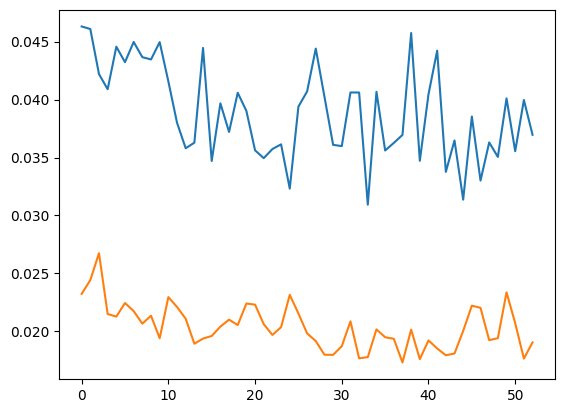

In [177]:
plt.plot(history15.history['loss'])
plt.plot(history15.history['val_loss'])

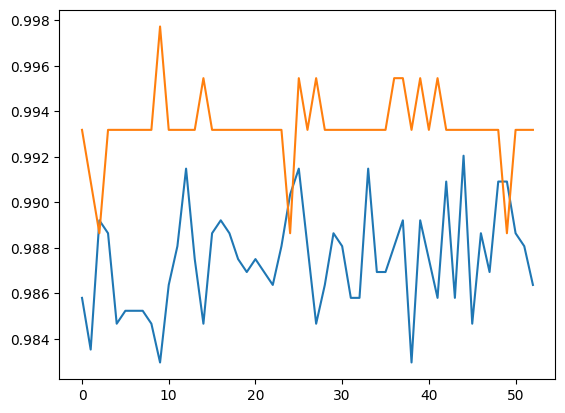

In [182]:
plt.plot(history15.history['accuracy'])
plt.plot(history15.history['val_accuracy'])

In [179]:
optimised_model.save("optimised_crop_model.keras")

In [180]:
pd.DataFrame(history15.history).to_csv("training_history.csv", index=False)